## RGB composite images

An RGB composite combines three separate data fields — one for each of
the red, green and blue colour channels — into a single true-colour (or
false-colour) image.  This technique is widely used with satellite imagery
to produce natural-looking scenes or to highlight specific atmospheric or
surface features.

In this example we retrieve three visible channels from a Meteosat Second
Generation (MSG) satellite swath via MARS and combine them into a
composite image.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

### Fetching the data

We request channels 1, 2 and 3 of MSG instrument 210 (SEVIRI) in a single
MARS request by passing a slash-separated list to the `channel` key.
earthkit-data returns a three-field FieldList — one field per channel —
which we can index directly.

In [ ]:
data = ekd.from_source(
    "mars",
    **{
        "channel": "3/2/1",
        "class": "od",
        "date": -1,
        "ident": "71",
        "instrument": "210",
        "param": "260512",
        "step": "12",
        "stream": "oper",
        "time": "00:00:00",
        "type": "ssd",
        "grid": "0.1/0.1",
    },
).to_fieldlist()

### High-level API: `ekp.geo.rgb_composite`

For a quick single-panel composite over a specific domain, use the
high-level `earthkit.plots.rgb_composite` function.  earthkit-plots
normalises each channel to the range [0, 1] automatically before
combining them, so you do not need to pre-process the data.

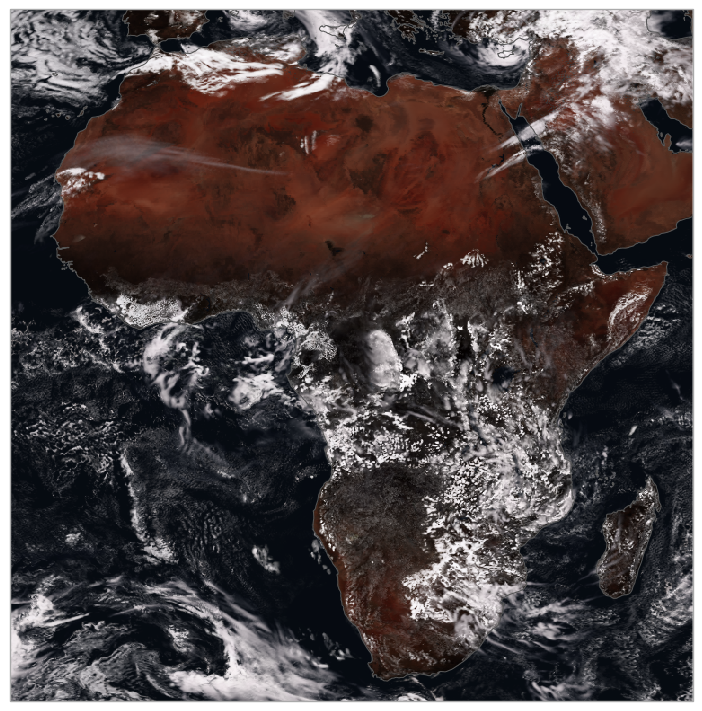

In [3]:
ekp.geo.rgb_composite(data, domain="Africa").show()

### Visualising individual channels

Before compositing it can be helpful to look at the individual channels.
Each channel captures slightly different wavelengths of visible light, so
bright regions in one channel may be darker in another.

We create a 2×2 figure, plot each channel in its natural colour, then
reserve the last panel for the composite.

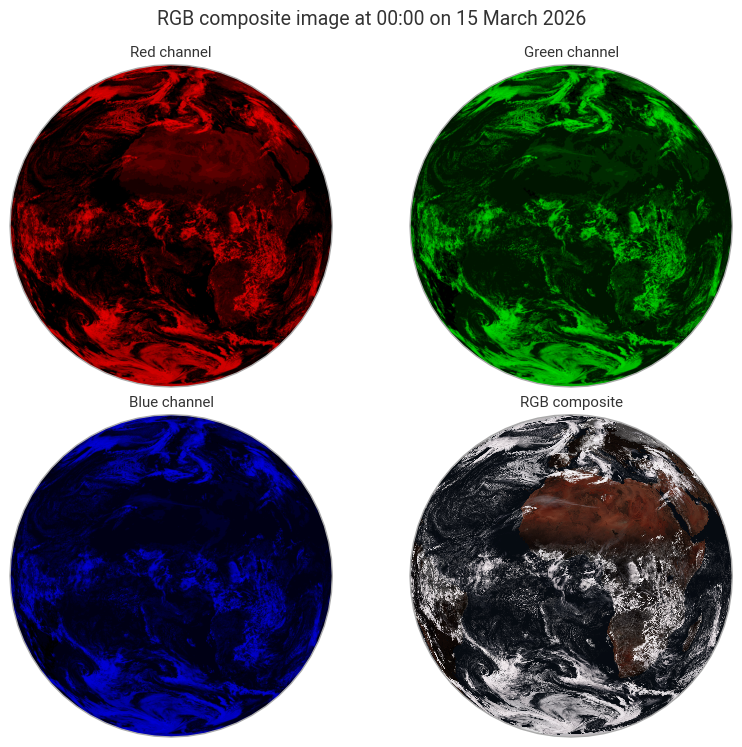

In [4]:
import cartopy.crs as ccrs

COLORS = {
    "red": (1, 0, 0),
    "green": (0, 1, 0),
    "blue": (0, 0, 1),
}

figure = ekp.Figure(crs=ccrs.NearsidePerspective(), rows=2, columns=2)

for i, color in enumerate(COLORS):
    channel_plot = figure.add_map()
    channel_plot.grid_cells(data[i], colors=["black", COLORS[color]])
    channel_plot.title(f"{color} channel")

composite = figure.add_map()
composite.rgb_composite(data)
composite.title("RGB composite")

figure.title("RGB composite image at {time:%H:%M on %-d %B %Y}")
figure.show()